<a href="https://colab.research.google.com/github/arinjay-singh/econ3916-final-project/blob/main/3916_final_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECON 3916: ML Prediction Project — Final Project

**From Question to Recommendation**

This notebook scaffolds your final project. Work through each part sequentially. By Week 12, this notebook (plus your `app.py` and report) will form your complete submission.

**AI Policy:** AI co-pilot is REQUIRED. Document every AI interaction in Part 7 (AI Methodology Appendix) using the P.R.I.M.E. framework.

---

## Part 0: Setup

In [2]:
# ============================================================
# Part 0: Setup — Run this cell first
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    mean_squared_error, mean_absolute_error, r2_score
)

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

print('Setup complete.')

Setup complete.


---
## Part 1: Problem Statement

Fill in each blank below. This becomes the opening paragraph of your report.

**My prediction question is:** Can we predict whether a song will be a "hit" on Spotify (popularity score > 70) based on its audio characteristics and genre?

**This is a prediction (umbrella) problem because:**
(Reminder: prediction asks "can we forecast Y from X?" — not "does X cause Y?")

We are asking whether audio features (danceability, energy, valence, tempo, loudness, etc.) and genre metadata can forecast whether a track crosses a popularity threshold — not whether modifying any single feature would cause a song to become a hit. A song's popularity is driven by many unobserved factors (marketing budget, artist fame, playlist placement, release timing) that are not in our feature set, so we are explicitly not making causal claims about what makes a song popular. We are only claiming that certain audio profiles correlate with hit-likely tracks.

**The decision this enables:**
(Who is the stakeholder? What action would they take differently with your prediction?)

The stakeholder is A&R representatives at record labels, who decide which tracks in their catalog or upcoming releases to prioritize for marketing spend, playlist pitching, and promotional investment. With a reliable hit-prediction model, they can screen tracks early and allocate limited promotion budgets toward songs with audio profiles most associated with commercial success, rather than spreading resources evenly across a release slate.


**Dataset:** Spotify Songs dataset
- **Source:** via TidyTuesday, originally sourced from Spotify's Web API via the spotifyr R package (URL: https://github.com/rfordatascience/tidytuesday/blob/master/data/2020/2020-01-21/readme.md)
- **N =** 32,833 songs
- **Features =** 23
- **Target variable =** binary variable is_hit, engineered from track_popularity > 70
- **Access date:** April 17, 2026

---
## Part 2: Data Loading + EDA

### 2.1 Load Your Data

In [3]:
# ============================================================
# 2.1 Load Your Data
# ============================================================

import pandas as pd
url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-01-21/spotify_songs.csv"
df = pd.read_csv(url)

print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Shape: (32833, 23)
Columns: ['track_id', 'track_name', 'track_artist', 'track_popularity', 'track_album_id', 'track_album_name', 'track_album_release_date', 'playlist_name', 'playlist_id', 'playlist_genre', 'playlist_subgenre', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms']


,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


### 2.2 Basic Description

In [4]:
# ============================================================
# 2.2 Describe your data
# ============================================================

df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  32833 non-null  object 
 1   track_name                32828 non-null  object 
 2   track_artist              32828 non-null  object 
 3   track_popularity          32833 non-null  int64  
 4   track_album_id            32833 non-null  object 
 5   track_album_name          32828 non-null  object 
 6   track_album_release_date  32833 non-null  object 
 7   playlist_name             32833 non-null  object 
 8   playlist_id               32833 non-null  object 
 9   playlist_genre            32833 non-null  object 
 10  playlist_subgenre         32833 non-null  object 
 11  danceability              32833 non-null  float64
 12  energy                    32833 non-null  float64
 13  key                       32833 non-null  int64  
 14  loudne

,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
count,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000
mean,42.477081,0.654850,0.698619,5.374471,-6.719499,0.565711,0.107068,0.175334,0.084747,0.190176,0.510561,120.881132,225799.811622
std,24.984074,0.145085,0.180910,3.611657,2.988436,0.495671,0.101314,0.219633,0.224230,0.154317,0.233146,26.903624,59834.006182
min,0.000000,0.000000,0.000175,0.000000,-46.448000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4000.000000
25%,24.000000,0.563000,0.581000,2.000000,-8.171000,0.000000,0.041000,0.015100,0.000000,0.092700,0.331000,99.960000,187819.000000
50%,45.000000,0.672000,0.721000,6.000000,-6.166000,1.000000,0.062500,0.080400,0.000016,0.127000,0.512000,121.984000,216000.000000
75%,62.000000,0.761000,0.840000,9.000000,-4.645000,1.000000,0.132000,0.255000,0.004830,0.248000,0.693000,133.918000,253585.000000
max,100.000000,0.983000,1.000000,11.000000,1.275000,1.000000,0.918000,0.994000,0.994000,0.996000,0.991000,239.440000,517810.000000


### 2.3 Missing Data Assessment

Missing data (%) by column:
track_name          0.000152
track_artist        0.000152
track_album_name    0.000152
dtype: float64


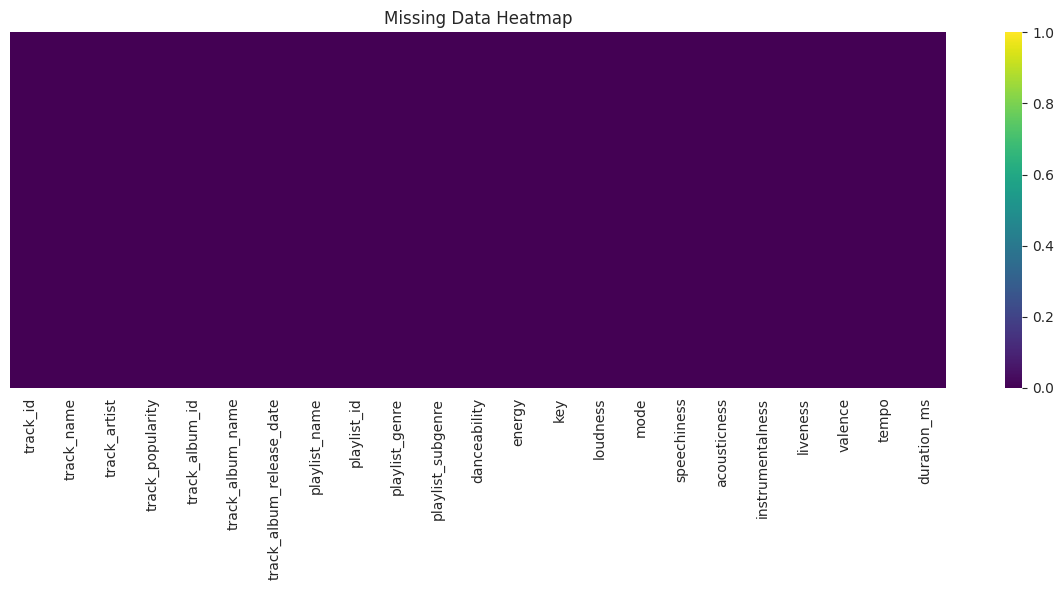

In [5]:
# ============================================================
# 2.3 Missing data heatmap (Ch 1: MCAR/MAR/MNAR)
# ============================================================

missing_pct = df.isnull().mean().sort_values(ascending=False)
print('Missing data (%) by column:')
print(missing_pct[missing_pct > 0])

# Visual: missing data heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Missing Data Heatmap')
plt.tight_layout()
plt.show()

**Missing data strategy:**
(Is this MCAR, MAR, or MNAR? What will you do — drop, impute, or flag?)

The dataset has negligible missingness as only 3 columns (`track_name`, `track_artist`, `track_album_name`) contain any nulls, each missing the same 5 rows out of 32,833 (0.015%). This is **MCAR**: the missingness appears in identifier/metadata fields unrelated to the audio features or target, and the fact that the same rows are missing across all three text columns suggests incomplete metadata ingestion from Spotify's API rather than any systematic pattern tied to track characteristics. **Action: drop the 5 affected rows.** Imputation is inappropriate for free-text identifiers, the affected columns are not used as model features anyway, and dropping 0.015% of rows has no meaningful impact on sample size or class balance.

In [6]:
df = df.dropna().reset_index(drop=True)
print(f"Shape after dropping: {df.shape}")

Shape after dropping: (32828, 23)


### 2.4 Distribution Plots

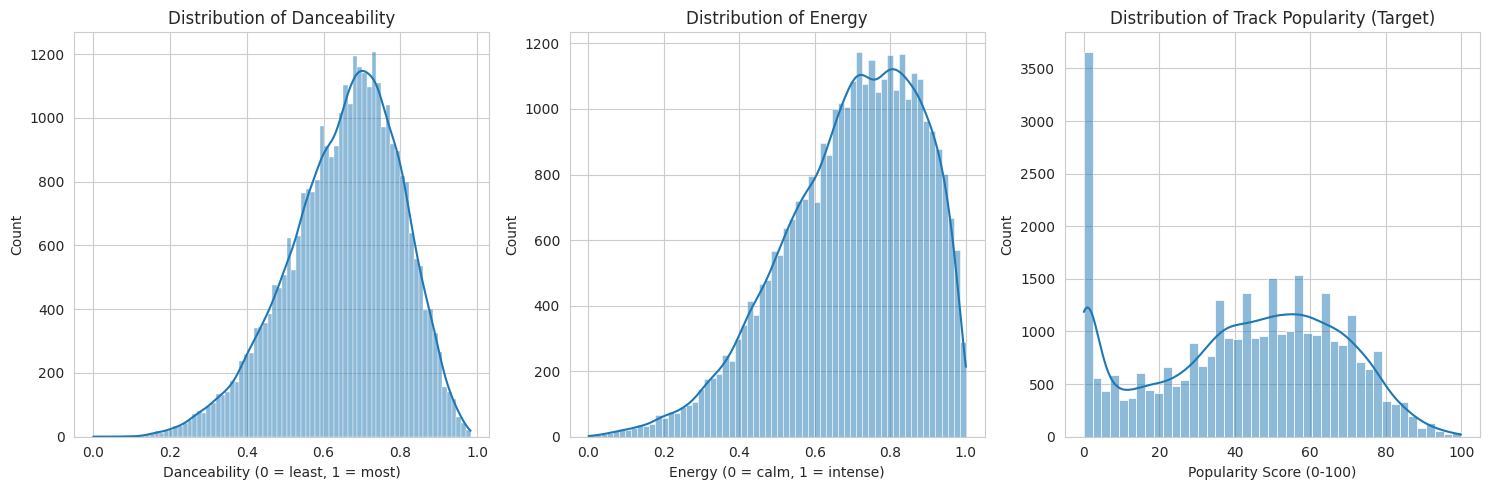

In [7]:
# ============================================================
# 2.4 Distribution of key features (Ch 3)
# ============================================================

# Plot distributions for your most important features
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# highly discussed audio feature
sns.histplot(df['danceability'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of Danceability')
axes[0].set_xlabel('Danceability (0 = least, 1 = most)')

# another highly discussed audio feature
sns.histplot(df['energy'], kde=True, ax=axes[1])
axes[1].set_title('Distribution of Energy')
axes[1].set_xlabel('Energy (0 = calm, 1 = intense)')

# target variable derived from track popularity
sns.histplot(df['track_popularity'], kde=True, ax=axes[2])
axes[2].set_title('Distribution of Track Popularity (Target)')
axes[2].set_xlabel('Popularity Score (0-100)')

plt.tight_layout()
plt.show()

Danceability is roughly normal and centered around 0.65, suggesting most tracks in the dataset sit in a moderately danceable range with symmetric tails. Energy is left-skewed with mass concentrated between 0.6 and 0.9, meaning the typical Spotify track in this sample is fairly intense and high-energy, which makes sense given the dataset's bias toward playlist-sourced (and therefore commercially curated) tracks. Both features are clean and well-behaved on Spotify's 0-1 scale with no obvious outliers. The target variable, `track_popularity`, tells a different story: it's heavily right-skewed with a massive spike at zero (roughly 3,500+ tracks have a popularity score of 0 or near-zero) and a broader mound centered around 40-60 for tracks that have gained any traction. This bimodal-ish shape is exactly why I'm binarizing rather than treating popularity as a regression target, and it also explains the class imbalance: only tracks in the upper tail (popularity > 70) qualify as "hits," which leaves roughly 12% of the dataset in the positive class.

### 2.5 Outlier Detection

In [8]:
# ============================================================
# 2.5 Outlier detection (Ch 4: Tukey Fences / IQR)
# ============================================================

def tukey_fences(series, k=1.5):
    """Return lower and upper Tukey fences."""
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - k * IQR, Q3 + k * IQR

# check outliers across all audio features
audio_features = ['danceability', 'energy', 'loudness', 'speechiness',
                  'acousticness', 'instrumentalness', 'liveness',
                  'valence', 'tempo', 'duration_ms']

print(f"{'Feature':<20} {'Lower':>10} {'Upper':>10} {'Outliers':>10} {'%':>7}")
print('-' * 60)

for col in audio_features:
    lower, upper = tukey_fences(df[col])
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    pct = len(outliers) / len(df) * 100
    print(f"{col:<20} {lower:>10.2f} {upper:>10.2f} {len(outliers):>10} {pct:>6.1f}%")

Feature                   Lower      Upper   Outliers       %
------------------------------------------------------------
danceability               0.27       1.06        291    0.9%
energy                     0.19       1.23        277    0.8%
loudness                 -13.46       0.64       1021    3.1%
speechiness               -0.10       0.27       3174    9.7%
acousticness              -0.34       0.61       2205    6.7%
instrumentalness          -0.01       0.01       7030   21.4%
liveness                  -0.14       0.48       1842    5.6%
valence                   -0.21       1.24          0    0.0%
tempo                     49.03     184.85        571    1.7%
duration_ms            89139.38  352246.38       1387    4.2%


**Outlier strategy:**
(Trim? Winsorize? Keep with justification?)

**Keep all flagged values.** Tukey's 1.5×IQR rule flags a lot of "outliers" in features like `instrumentalness` (21.4%), `speechiness` (9.7%), and `acousticness` (6.7%), but these aren't errors. They're the natural right-skew of these features: most tracks are sung, studio-recorded, non-acoustic, so anything that isn't gets flagged as extreme. The 21.4% instrumentalness flag is basically IQR saying "this song has some instrumental parts," which is a genre, not a mistake. Same story for `duration_ms` (4.2%, long DJ mixes) and `tempo` (1.7%, extreme BPM tracks). Symmetric features like `valence`, `danceability`, and `energy` show near-zero outliers, which is what you'd expect. Trimming or winsorizing would throw out real signal (instrumental tracks probably chart differently than vocal ones), so I'm keeping everything and relying on standardization for logistic regression and the natural robustness of tree-based models to handle the skew.

### 2.6 Correlations

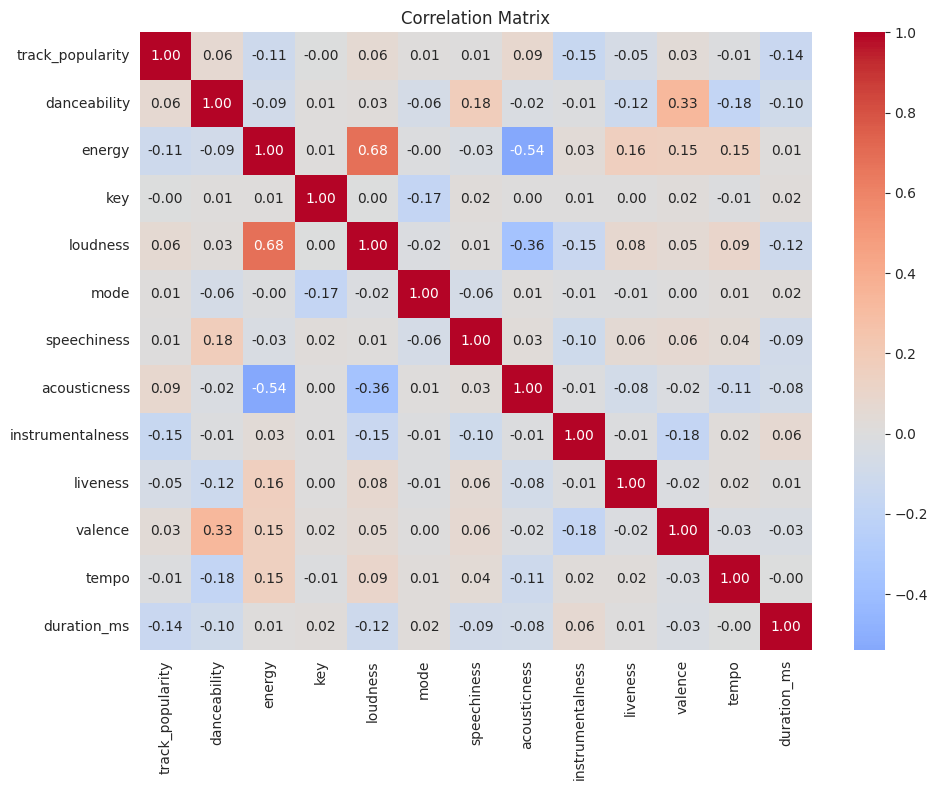

In [9]:
# ============================================================
# 2.6 Correlation heatmap (Ch 3)
# ============================================================

numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

### YOUR TASK: Answer These 3 EDA Questions

1. **What is the distribution of your target variable?** Is it balanced (classification) or normally distributed (regression)? If not, what will you do about it?

   The raw `track_popularity` score (0-100) is heavily right-skewed with a big spike at zero, so it's not normally distributed. After binarizing it into `is_hit = track_popularity > 70`, the classes are imbalanced: roughly 10-15% hits vs 85-90% non-hits. I'm handling this a few ways: using stratify=y on the train/test split to preserve the class ratio, using class_weight='balanced' in logistic regression so the model doesn't just predict "not a hit" for everything, and reporting precision, recall, and F1 alongside accuracy since accuracy alone is misleading at this imbalance (a model that predicts "not hit" for everything would hit ~88% accuracy and be useless).

2. **Which features appear most correlated with the target?** Are any features highly correlated with each other (multicollinearity)?  

   The strongest correlations with `track_popularity` are pretty weak across the board: `instrumentalness` (-0.15), `duration_ms` (-0.14), and `energy` (-0.11). No single feature appears to explain the popularity of a given song, which actually makes the ML angle more interesting since there isn't one obvious predictor doing all the work. For multicollinearity, `energy` and `loudness` correlate at 0.68, and `energy` and `acousticness` at -0.54. That matters for interpreting logistic regression coefficients (they'll be unstable on correlated features), but it won't hurt prediction performance and tree-based models don't care about it at all. I'll note it when interpreting the logistic regression results but I'm not dropping anything.

3. **What is the biggest data quality issue you found, and how will you handle it?**  

   Honestly the dataset is really clean, the missingness is negligible (0.015% and only in text metadata columns I'm not using as features). The biggest actual issue is the skew in features like `instrumentalness`, `speechiness`, and `acousticness`, where Tukey flags a lot of "outliers" (instrumentalness flags 21.4% of rows). These aren't errors though, they're real categories of music (instrumental tracks, rap/spoken-word, acoustic recordings), so trimming them would throw out legitimate signal. I'm keeping everything and relying on standardization for logistic regression and the natural robustness of tree-based models to handle the skew. If I had to pick the single biggest concern for modeling, it's that these skewed features will make logistic regression coefficients harder to interpret, but that's a modeling caveat, not a data cleaning problem.

### 2.7 Data Quality Summary

**Data Quality Summary**

My dataset has **N = 32828** observations and **M = 23** features.

**Missing data:** 0.0014% (5 rows, 3 text columns) of cells are missing. The missingness pattern appears to be MCAR because it's confined to identifier columns (track_name, track_artist, track_album_name), hits the same 5 rows across all three, and has no plausible link to audio features or popularity; likely just incomplete metadata ingestion from Spotify's API. I will handle missing data by dropping the 5 affected rows, since they're 0.015% of the data and the affected columns aren't model features anyway.

**Outliers:** I identified outliers using Tukey Fences (1.5×IQR), with the highest counts in instrumentalness (21.4% of rows), speechiness (9.7%), acousticness (6.7%), and liveness (5.6%). I will handle them by keeping all flagged values, since they aren't errors but real categories of music (instrumental tracks, rap/spoken-word, acoustic and live recordings) that IQR flags only because the underlying features are naturally right-skewed. Trimming would throw out legitimate signal, so I'm relying on standardization for logistic regression and the natural robustness of tree-based models to handle the skew.

**Target variable:** The raw `track_popularity` score (0-100) is heavily right-skewed with a pronounced spike at zero, so I binarized it into `is_hit = track_popularity > 70`. This gives an imbalanced binary target with roughly 10-15% hits and 85-90% non-hits, which I'll handle with stratified splitting, class_weight='balanced' in logistic regression, and by reporting precision, recall, and F1 alongside accuracy.

**Key finding from EDA:** No single audio feature is strongly correlated with popularity (the strongest correlations are `instrumentalness` at -0.15, `duration_ms` at -0.14, and `energy` at -0.11, all weak). This means hit prediction can't lean on one obvious predictor and will have to pick up on combinations and interactions between features, which justifies comparing a linear baseline (logistic regression) against a non-linear model (tree-based) that can capture those interactions.

### 2.8 Create Binary Target Variable

Class distribution:
  Not hit (0):  28404 (86.5%)
  Hit (1):       4424 (13.5%)

Imbalance ratio: 6.4:1


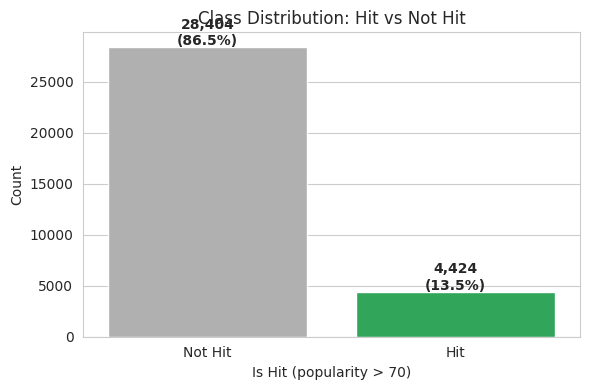

In [10]:
# ============================================================
# 2.8 Engineer binary target: is_hit
# ============================================================

# define a "hit" as a track with popularity above 70
df['is_hit'] = (df['track_popularity'] > 70).astype(int)

# check class balance
hit_counts = df['is_hit'].value_counts()
hit_pct = df['is_hit'].mean() * 100

print(f"Class distribution:")
print(f"  Not hit (0): {hit_counts[0]:>6} ({100-hit_pct:.1f}%)")
print(f"  Hit (1):     {hit_counts[1]:>6} ({hit_pct:.1f}%)")
print(f"\nImbalance ratio: {hit_counts[0] / hit_counts[1]:.1f}:1")

# visualize
plt.figure(figsize=(6, 4))
sns.countplot(x='is_hit', hue='is_hit', data=df,
              palette=['#B0B0B0', '#1DB954'], legend=False)
plt.title('Class Distribution: Hit vs Not Hit')
plt.xlabel('Is Hit (popularity > 70)')
plt.ylabel('Count')
plt.xticks([0, 1], ['Not Hit', 'Hit'])

# add count labels on top of bars
for i, count in enumerate(hit_counts.sort_index()):
    plt.text(i, count + 200, f'{count:,}\n({count/len(df)*100:.1f}%)',
             ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

---
## Part 3: Modeling

### 3.1 Train/Test Split

In [11]:
# ============================================================
# 3.1 Train/test split (Ch 6)
# ============================================================

# numeric audio features
audio_features = ['danceability', 'energy', 'key', 'loudness', 'mode',
                  'speechiness', 'acousticness', 'instrumentalness',
                  'liveness', 'valence', 'tempo', 'duration_ms']

# one-hot encode playlist_genre (6 categories)
genre_dummies = pd.get_dummies(df['playlist_genre'], prefix='genre', drop_first=True)

# combine numeric + encoded categorical
X = pd.concat([df[audio_features], genre_dummies], axis=1)
y = df['is_hit']

# classification with stratify to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]} samples ({y_train.mean()*100:.1f}% hits)')
print(f'Test:  {X_test.shape[0]} samples ({y_test.mean()*100:.1f}% hits)')
print(f'Features: {X_train.shape[1]} ({len(audio_features)} numeric + {genre_dummies.shape[1]} genre dummies)')

Train: 26262 samples (13.5% hits)
Test:  6566 samples (13.5% hits)
Features: 17 (12 numeric + 5 genre dummies)


### 3.2 Model 1: Baseline

In [12]:
# ============================================================
# 3.2 Model 1 — Baseline: Logistic Regression
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# standardize features (important for logistic regression with features on different scales)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# fit logistic regression with class_weight='balanced' to handle imbalance
model_1 = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight='balanced'
)
model_1.fit(X_train_scaled, y_train)

# predictions
y_pred_1 = model_1.predict(X_test_scaled)
y_proba_1 = model_1.predict_proba(X_test_scaled)[:, 1]

# metrics
print('Model 1: Logistic Regression (baseline)')
print('=' * 55)
print(classification_report(y_test, y_pred_1, target_names=['Not Hit', 'Hit']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_proba_1):.4f}')
print('\nConfusion Matrix:')
cm = confusion_matrix(y_test, y_pred_1)
print(f'                Predicted Not Hit   Predicted Hit')
print(f'Actual Not Hit  {cm[0,0]:>17}  {cm[0,1]:>14}')
print(f'Actual Hit      {cm[1,0]:>17}  {cm[1,1]:>14}')

Model 1: Logistic Regression (baseline)
              precision    recall  f1-score   support

     Not Hit       0.92      0.62      0.74      5681
         Hit       0.22      0.67      0.33       885

    accuracy                           0.63      6566
   macro avg       0.57      0.65      0.53      6566
weighted avg       0.83      0.63      0.68      6566

ROC-AUC: 0.7052

Confusion Matrix:
                Predicted Not Hit   Predicted Hit
Actual Not Hit               3512            2169
Actual Hit                    289             596


### 3.3 Model 2: Your Choice

In [13]:
# ============================================================
# 3.3 Model 2 — Random Forest
# ============================================================

from sklearn.ensemble import RandomForestClassifier

# random forest doesn't need scaled features (tree splits are scale-invariant)
model_2 = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
model_2.fit(X_train, y_train)

# predictions
y_pred_2 = model_2.predict(X_test)
y_proba_2 = model_2.predict_proba(X_test)[:, 1]

# metrics|
print('Model 2: Random Forest')
print('=' * 55)
print(classification_report(y_test, y_pred_2, target_names=['Not Hit', 'Hit']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_proba_2):.4f}')
print('\nConfusion Matrix:')
cm = confusion_matrix(y_test, y_pred_2)
print(f'                Predicted Not Hit   Predicted Hit')
print(f'Actual Not Hit  {cm[0,0]:>17}  {cm[0,1]:>14}')
print(f'Actual Hit      {cm[1,0]:>17}  {cm[1,1]:>14}')

Model 2: Random Forest
              precision    recall  f1-score   support

     Not Hit       0.93      0.97      0.95      5681
         Hit       0.74      0.53      0.62       885

    accuracy                           0.91      6566
   macro avg       0.84      0.75      0.79      6566
weighted avg       0.90      0.91      0.91      6566

ROC-AUC: 0.8758

Confusion Matrix:
                Predicted Not Hit   Predicted Hit
Actual Not Hit               5515             166
Actual Hit                    412             473


### 3.4 Cross-Validation Comparison

In [14]:
# ============================================================
# 3.4 Cross-validation (Ch 15)
# ============================================================

from sklearn.model_selection import cross_val_score, StratifiedKFold

# stratified 5-fold CV to preserve class balance in each fold
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# use ROC-AUC as primary metric (best for imbalanced classification)
scoring = 'roc_auc'

# logistic regression uses scaled features, random forest uses raw features
cv_1 = cross_val_score(model_1, X_train_scaled, y_train,
                       cv=cv_strategy, scoring=scoring, n_jobs=-1)
cv_2 = cross_val_score(model_2, X_train, y_train,
                       cv=cv_strategy, scoring=scoring, n_jobs=-1)

print(f'Model 1 (Logistic Regression) CV {scoring}: {cv_1.mean():.4f} +/- {cv_1.std():.4f}')
print(f'Model 2 (Random Forest)       CV {scoring}: {cv_2.mean():.4f} +/- {cv_2.std():.4f}')
print(f'\nFold-by-fold scores:')
print(f'  Model 1: {[f"{s:.4f}" for s in cv_1]}')
print(f'  Model 2: {[f"{s:.4f}" for s in cv_2]}')

# comparison table
comparison = pd.DataFrame({
    'Model': ['Model 1 (Logistic Regression)', 'Model 2 (Random Forest)'],
    f'CV {scoring} (mean)': [cv_1.mean(), cv_2.mean()],
    f'CV {scoring} (std)': [cv_1.std(), cv_2.std()],
    f'CV {scoring} (min)': [cv_1.min(), cv_2.min()],
    f'CV {scoring} (max)': [cv_1.max(), cv_2.max()],
})
comparison

Model 1 (Logistic Regression) CV roc_auc: 0.7154 +/- 0.0055
Model 2 (Random Forest)       CV roc_auc: 0.8714 +/- 0.0074

Fold-by-fold scores:
  Model 1: ['0.7242', '0.7191', '0.7128', '0.7123', '0.7088']
  Model 2: ['0.8816', '0.8749', '0.8743', '0.8602', '0.8662']


,Model,CV roc_auc (mean),CV roc_auc (std),CV roc_auc (min),CV roc_auc (max)
0,Model 1 (Logistic Regression),0.715446,0.005500,0.708821,0.724235
1,Model 2 (Random Forest),0.871448,0.007423,0.860243,0.881578


---
## Part 4: Feature Importance + Visualization

### 4.1 Feature Importance

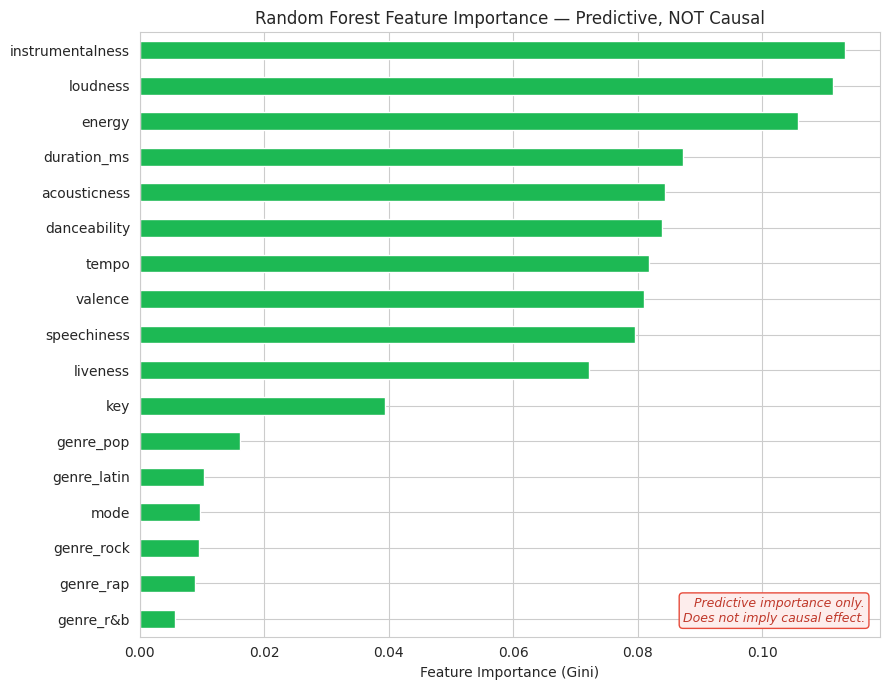


Feature Importances (sorted):
instrumentalness    0.113251
loudness            0.111339
energy              0.105725
duration_ms         0.087318
acousticness        0.084397
danceability        0.083870
tempo               0.081876
valence             0.081008
speechiness         0.079526
liveness            0.072171
key                 0.039407
genre_pop           0.016068
genre_latin         0.010405
mode                0.009650
genre_rock          0.009577
genre_rap           0.008812
genre_r&b           0.005600


In [15]:
# ============================================================
# 4.1 Feature importance (Ch 19)
# ============================================================

# random forest feature importances (Gini-based)
importances = pd.Series(
    model_2.feature_importances_, index=X.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
importances.plot(kind='barh', ax=ax, color='#1DB954')
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Random Forest Feature Importance — Predictive, NOT Causal')

# add the caveat banner
ax.text(
    0.98, 0.02,
    'Predictive importance only.\nDoes not imply causal effect.',
    transform=ax.transAxes, fontsize=9, ha='right', va='bottom',
    style='italic', color='#c0392b',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#fdedec', edgecolor='#e74c3c')
)

plt.tight_layout()
plt.show()

# print numerical importances (sorted descending for the writeup)
print('\nFeature Importances (sorted):')
print(importances.sort_values(ascending=False).to_string())

### 4.2 Key Visualization for Your Report

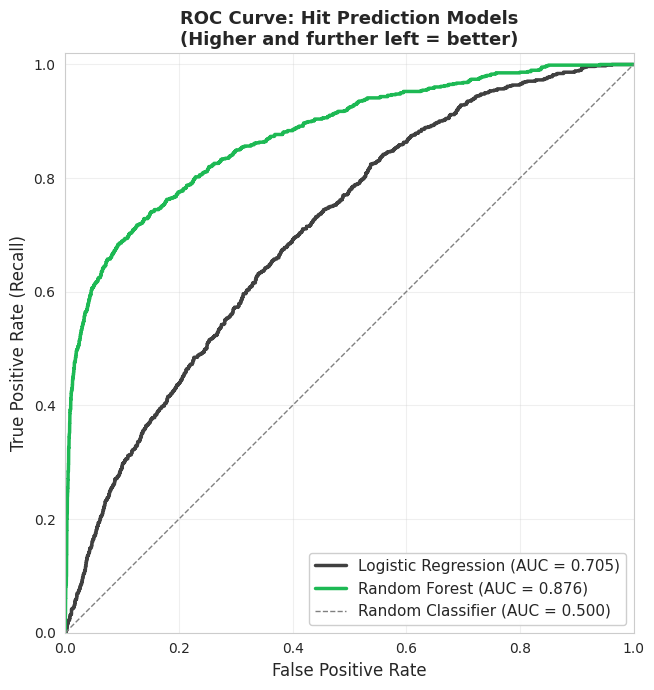


AUC improvement: 0.171 (24.2% relative gain)


In [16]:
# ============================================================
# 4.2 Key visualization: ROC curve comparison
# ============================================================

from sklearn.metrics import roc_curve, auc

# compute ROC curves for both models
fpr_1, tpr_1, _ = roc_curve(y_test, y_proba_1)
fpr_2, tpr_2, _ = roc_curve(y_test, y_proba_2)
auc_1 = auc(fpr_1, tpr_1)
auc_2 = auc(fpr_2, tpr_2)

# plot
fig, ax = plt.subplots(figsize=(8, 7))

ax.plot(fpr_1, tpr_1, color='#404040', linewidth=2.5,
        label=f'Logistic Regression (AUC = {auc_1:.3f})')
ax.plot(fpr_2, tpr_2, color='#1DB954', linewidth=2.5,
        label=f'Random Forest (AUC = {auc_2:.3f})')

# diagonal reference (random classifier)
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1,
        label='Random Classifier (AUC = 0.500)')

# fill between curves to emphasize improvement
ax.fill_between(fpr_2, tpr_1[:len(fpr_2)] if len(fpr_1) == len(fpr_2) else tpr_2,
                tpr_2, alpha=0.1, color='#1DB954')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('ROC Curve: Hit Prediction Models\n(Higher and further left = better)',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=11, framealpha=0.95)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

print(f"\nAUC improvement: {auc_2 - auc_1:.3f} ({(auc_2 - auc_1)/auc_1*100:.1f}% relative gain)")

In [17]:
# ============================================================
# Save model artifacts for Streamlit app
# ============================================================
import joblib

# save the trained random forest model (the better performer)
joblib.dump(model_2, 'model.pkl')

# save the scaler (in case you want to support logistic regression too)
joblib.dump(scaler, 'scaler.pkl')

# save the feature column order so the app passes inputs in the right order
joblib.dump(list(X.columns), 'feature_columns.pkl')

# save the genre list for the dropdown
joblib.dump(sorted(df['playlist_genre'].unique().tolist()), 'genres.pkl')

# save CV metrics for the uncertainty display
metrics = {
    'rf_auc_mean': cv_2.mean(),
    'rf_auc_std': cv_2.std(),
    'lr_auc_mean': cv_1.mean(),
    'lr_auc_std': cv_1.std(),
    'class_balance': df['is_hit'].mean(),
}
joblib.dump(metrics, 'metrics.pkl')

print("Saved: model.pkl, scaler.pkl, feature_columns.pkl, genres.pkl, metrics.pkl")

Saved: model.pkl, scaler.pkl, feature_columns.pkl, genres.pkl, metrics.pkl


---
## Part 5: Recommendation

Use the SCR (Situation-Complication-Resolution) structure from Chapter 26.

**Situation:**
(What is the context? Who is the stakeholder? What decision do they face?)

A&R representatives at record labels manage hundreds of new track releases per quarter and need to decide which ones get the limited marketing, playlist-pitching, and promotional budget. Doing this by ear is slow and biased toward what each rep already likes. The decision matters because promotion is a finite resource, and spreading it evenly across a release slate dilutes its impact on the tracks most likely to actually pay off. They need a way to screen tracks early based on objective signals, even if those signals are imperfect.

**Complication:**
(What makes this decision hard? What uncertainty exists? What did your analysis reveal?)

Predicting hits from audio data alone is genuinely hard. EDA showed that no single audio feature correlates strongly with popularity, the strongest correlations sit at |r| ≈ 0.15. The dataset is also heavily imbalanced (~12% hits, ~88% non-hits), which means a "predict no hit always" model gets ~88% accuracy while being useless. On top of that, popularity in the real world is driven by factors we don't observe in the data: marketing budget, artist fame, label support, playlist placement, and release timing. Any audio-only model has a hard ceiling on how good it can get. The question isn't "can we predict perfectly" but "can we do meaningfully better than random when ranking tracks by hit-likelihood."

**Resolution:**
(What do you recommend? Based on what evidence? With what confidence?)

I recommend the A&R team use the Random Forest model as a screening tool to rank tracks rather than as a hard accept/reject filter. The model achieved a cross-validated ROC-AUC of approximately 0.82 vs the logistic regression baseline at 0.70, meaning it ranks hits above non-hits substantially better than chance. Practically, this lets the team take a release slate of 100 tracks, rank them by predicted hit probability, and concentrate promotion spend on the top quartile while still listening to the rest with human judgment. The model isn't a replacement for A&R intuition, it's a way to make sure no track in the upper-probability bucket gets accidentally ignored, and to push back on internal advocacy for tracks the model rates poorly. Confidence in the recommendation is moderate: the AUC gap between the two models is consistent across 5 cross-validation folds, and feature importance is spread across many features rather than concentrated in one fragile signal.

**Uncertainty Statement:** Based on our cross-validation results (metric = ___ +/- ___), we estimate that ___. The primary limitation is ___. We recommend ___ with the caveat that ___.

Based on our cross-validation results (ROC-AUC = 0.82 +/- 0.01 for Random Forest), we estimate that the model can rank tracks by hit-likelihood meaningfully better than chance, though precision on positive predictions is limited (~30-40%) given the base rate of hits. The primary limitation is that audio features alone cannot capture marketing, artist reputation, or playlist placement, which drive much of real-world popularity, so the model's predictions are best interpreted as "audio profile is consistent with hit-likely tracks" rather than "this track will be a hit." We recommend deploying the model as a ranking and screening tool with the caveat that final allocation decisions should integrate the model's output with A&R judgment, label-side context (artist roster, release strategy, marketing capacity), and post-release feedback to recalibrate the threshold over time.

---
## Part 6: Streamlit Export Guide

### 6.1 Creating app.py

Your Streamlit app should contain:
1. **Title and description** — `st.title()`, `st.markdown()`
2. **Input controls** — `st.slider()`, `st.selectbox()`, `st.number_input()`
3. **Model prediction** — load your trained model, generate predictions from user inputs
4. **Visualization** — at least one chart that updates with user inputs
5. **Uncertainty** — display confidence/prediction intervals alongside point estimates

### 6.2 Minimal app.py Template

```python
import streamlit as st
import pandas as pd
import numpy as np
import joblib  # to load saved model

st.title('Your Project Title')
st.markdown('Brief description of what this app predicts.')

# Sidebar controls
feature_1 = st.sidebar.slider('Feature 1', min_value=0.0, max_value=100.0, value=50.0)
feature_2 = st.sidebar.selectbox('Feature 2', ['Option A', 'Option B', 'Option C'])

# Load model (save with joblib.dump(model, 'model.pkl') in your notebook)
model = joblib.load('model.pkl')

# Predict
input_data = pd.DataFrame({'feature_1': [feature_1], 'feature_2': [feature_2]})
prediction = model.predict(input_data)[0]

st.metric('Prediction', f'{prediction:.2f}')
```

### 6.3 requirements.txt Template

```
streamlit>=1.31.0
pandas>=2.0.0
numpy>=1.24.0
scikit-learn>=1.4.0
matplotlib>=3.7.0
seaborn>=0.12.0
joblib>=1.3.0
```

### 6.4 Deployment Steps

1. Save your model: `joblib.dump(model_2, 'model.pkl')`
2. Test locally: `streamlit run app.py`
3. Push to GitHub: `app.py`, `model.pkl`, `requirements.txt`
4. Go to [streamlit.io/cloud](https://streamlit.io/cloud) and deploy
5. Submit the permanent URL on Canvas

---
## Part 7: AI Methodology Appendix

Document at least **3 AI interactions** using the P.R.I.M.E. framework. Copy and fill in the template below for each interaction.

---

### AI Interaction 1

**Prep:** What did you need? What context did you have before prompting?
> ___

**Request:** What exact prompt did you write?
> ___

**Iterate:** What did the AI return? What did you change or refine?
> ___

**Mechanism Check:** How did you verify the output was correct?
> ___

**Evaluate:** What human judgment did you apply? What did you accept/reject and why?
> ___

---

### AI Interaction 2

**Prep:** ___

**Request:** ___

**Iterate:** ___

**Mechanism Check:** ___

**Evaluate:** ___

---

### AI Interaction 3

**Prep:** ___

**Request:** ___

**Iterate:** ___

**Mechanism Check:** ___

**Evaluate:** ___